# ITC feed-back analysis — the §9 decentralization test

This notebook reads the 19 `itcfb` runs and answers the pre-registered §9
question: does the mandate's dual-derived ITC, fed back as a real credit with
the mandate removed, reproduce the mandate capacity trajectory?

The reading order is layered — each layer is a control for the next:

1. **fbA — misapplication control (R1).** The credit is added while the mandate
   stays on. Every previously binding floor dual must collapse to ~0. A
   persisting dual means the credit was misapplied; stop and reconcile.
2. **fbB — convex control (R2).** ITC only, learning off. In a convex model the
   dual-derived credit should reproduce the trajectory. This isolates the
   mechanics from the economics.
3. **fbC — the §9 test (R3).** ITC only, endogenous learning on. Pre-registered
   both ways: pass ⇒ the exogenous-price method is validated; fail ⇒ a finding —
   learning-by-doing makes the problem non-convex, exactly where marginal-price
   instruments can fail to decentralize a target.
4. **fbK — engine calibration (R4).** Mandate + learning, no ITC. The in-run
   learned cost path must reproduce the drawn p50 path, so an fbC failure can be
   attributed to economics rather than engine error.
5. **fbR — demand-curve anchors (R5).** Deployment at flat 0/30/50% credits.

The fed rates are the paper's headline ITC definition (`i_model_headline` from
`step3_analysis` t09) plus a 0.01 indifference bump, monetized at 0.9. ReEDS
applies the credit inside the finance multiplier. The p95 worlds and the
large100 family are excluded by design; the exclusions are findings, recorded
in `z-ethan/itc_feedback/run_manifest.md`.

Data-source discipline: duals come from the canonical QA exports
(`step3_checks/exports/duals_by_year.csv` for the base worlds,
`itcfb_checks/exports/duals_by_year.csv` for the 19 runs), never re-derived —
with a spot freshness check against the h5 files. The gap and calibration
tables come from `itcfb_checks/exports/`. The h5 files are read only for
capacity and cost series.

Run on the **playground-env** kernel. Requires drive D.
Run `itcfb_checks/itcfb_output_checks.ipynb` first: R0 gates on its registry.

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)

HERE = Path.cwd()
assert HERE.name == "itcfb_analysis", f"run from z-ethan/itcfb_analysis/, not {HERE}"
REPO = HERE.parents[1]
EXPORTS = HERE / "exports"
FIGURES = HERE / "figures"
EXPORTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
CHECKS3 = REPO / "z-ethan" / "step3_checks" / "exports"
CHECKSFB = REPO / "z-ethan" / "itcfb_checks" / "exports"
S3ANALYSIS = REPO / "z-ethan" / "step3_analysis" / "exports"

H5_DIR = Path("D:/ReEDS files/nuclear-learning/All runs so far")

# ---- case matrix ------------------------------------------------------------------
cases = pd.read_csv(REPO / "cases_nuclearlearning_itcfb.csv", index_col=0)
CASES = [c for c in cases.columns if c != "Default Value"]
assert len(CASES) == 19, len(CASES)

def sw(case, name):
    v = cases.loc[name, case]
    if pd.isna(v) or str(v).strip() == "":
        v = cases.loc[name, "Default Value"]
    return "" if pd.isna(v) else str(v).strip()

SCHEDULES = ["eia", "aj", "iaea", "mck", "cop28", "eo"]      # ordered by 2050 ambition
SCHED_LABEL = {"eia": "EIA AEO high (117 GW)", "aj": "Abou-Jaoude (134 GW)",
               "iaea": "IAEA high (172 GW)", "mck": "McKinsey (200 GW)",
               "cop28": "COP28 (300 GW)", "eo": "EO 2025 (400 GW)"}

def parse_case(c):
    parts = c.split("_")
    arm = parts[0]
    world = parts[1] if arm != "fbR" else "eia"
    return arm, world

META = {c: dict(arm=parse_case(c)[0], world=parse_case(c)[1],
                mandate=int(float(sw(c, "GSw_NuclearCapMandate"))),
                learning=int(float(sw(c, "GSw_NuclearLearning"))))
        for c in CASES}
ARM_CASES = {a: [c for c in CASES if META[c]["arm"] == a]
             for a in ["fbA", "fbB", "fbC", "fbK", "fbR"]}
BASE_OF_WORLD = {w: f"smr100_{w}_p50" for w in SCHEDULES}

H5 = {c: H5_DIR / f"itcfb_{c}_outputs.h5" for c in CASES}
for w in SCHEDULES:
    H5[BASE_OF_WORLD[w]] = H5_DIR / f"test1_{BASE_OF_WORLD[w]}_outputs.h5"

# ---- self-contained outputs.h5 reader (no `reeds` import: env/DLL constraints) --
_CACHE = {}

def load(case, key):
    if (case, key) in _CACHE:
        return _CACHE[(case, key)]
    with h5py.File(H5[case], "r") as f:
        if key not in f:
            raise KeyError(f"{key} not in {H5[case].name}")
        g = f[key]
        cols = [c.decode() for c in g["columns"][:]]
        data = {}
        for c in cols:
            arr = g[c][:]
            data[c] = arr.astype(str) if arr.dtype.kind == "S" else arr
        df = pd.DataFrame(data)[cols]
    for c in ("t", "allt"):
        if c in df.columns:
            df[c] = df[c].astype(int)
    _CACHE[(case, key)] = df
    return df

# 2022$ -> 2004$ deflator; 2004$ -> 2024$ display factor
DEFL = pd.read_csv(REPO / "inputs" / "financials" / "deflator.csv")
DEFL.columns = ["t", "Deflator"]
DEFL = DEFL.set_index("t")["Deflator"]
D2022 = float(DEFL.loc[2022])
TO2024 = 1.0 / float(DEFL.loc[2024])


In [2]:
# ---- house figure style: z-ethan/plotstyle.py is the normative standard -----------
import sys

sys.path.insert(0, str(HERE.parent))
import plotstyle as ps

ps.apply()
COL = ps.COL
INK, MUTED, FAINT, GRID_C, EDGE_C, SURFACE = (ps.INK, ps.MUTED, ps.FAINT,
                                              ps.GRID_C, ps.EDGE_C, ps.SURFACE)
assert SCHEDULES == ps.SCHED_ORDER, "schedule tokens diverged from plotstyle.SCHED_ORDER"
SCHED_C = dict(ps.SCHED_C)
BASE_C = ps.BASE_C

def savefig(fig, name):
    return ps.savefig(fig, FIGURES / name)


## R0 — Data assembly, QA gate, and freshness

The QA gate: the checks registry must show zero FAIL in phases A, B, and D
(file health, credit application, cross-case integrity). A phase-C FAIL is a
pre-registered finding, printed loudly and interpreted below, not a blocker.

In [3]:
summary = pd.read_csv(CHECKSFB / "checks_summary.csv")
hard = summary[(summary["status"] == "FAIL") & summary["phase"].isin(["A", "B", "D"])]
assert not len(hard), f"mechanical-integrity FAILs in itcfb_checks:\n{hard}"
c_fails = summary[(summary["status"] == "FAIL") & (summary["phase"] == "C")]
if len(c_fails):
    print("pre-registered criterion FAILs (interpreted below, not blockers):")
    print(c_fails[["check", "detail"]].to_string(index=False))
else:
    print("no phase-C failures: every pre-registered criterion passed in the checks")

# canonical duals + QA exports
DUALS3 = pd.read_csv(CHECKS3 / "duals_by_year.csv")
DUALSFB = pd.read_csv(CHECKSFB / "duals_by_year.csv")
assert set(DUALSFB["case"]) == set(CASES)
GAPS = pd.read_csv(CHECKSFB / "trajectory_gaps.csv")
RR = pd.read_csv(CHECKSFB / "rate_recovery.csv")
CAL = pd.read_csv(CHECKSFB / "fbK_calibration.csv")
COLLAPSE = pd.read_csv(CHECKSFB / "fbA_collapse.csv")

# t09: only the four refactor-stable columns
EPS, PEN = 0.01, 0.1
t09 = pd.read_csv(S3ANALYSIS / "t09_required_itc.csv",
                  usecols=["case", "t", "status", "i_model_headline"])
RATES = {}
for w in SCHEDULES:
    sub = t09[(t09["case"] == BASE_OF_WORLD[w]) & (t09["status"] == "rate")]
    RATES[w] = {int(t): round(float(i) + EPS, 3) * (1 - PEN)
                for t, i in zip(sub["t"], sub["i_model_headline"])}

# mandate trajectories
NL_DIR = REPO / "inputs" / "nuclear_learning"

def trajectory(scen):
    tr = pd.read_csv(NL_DIR / f"nuclear_cap_trajectory_{scen}.csv")
    tr.columns = [c.lstrip("*") for c in tr.columns]
    return tr.set_index(tr.columns[0])["MW"]

TRAJ = {w: trajectory(f)
        for w, f in [("eia", "eia_aeo_high_smr"), ("aj", "abou_jaoude_smr"),
                     ("iaea", "iaea_high_smr"), ("mck", "mckinsey_smr"),
                     ("cop28", "cop28_smr"), ("eo", "eo2025_smr")]}

YEARS_RUN = sorted(DUALSFB["t"].unique())
assert len(YEARS_RUN) == 16, YEARS_RUN


no phase-C failures: every pre-registered criterion passed in the checks


In [4]:
# ---- freshness spot test: the QA exports match the h5 files -----------------------
def h5_dual(case):
    with h5py.File(H5[case], "r") as f:
        if "nuclear_cap_price" not in f:
            return pd.Series(dtype=float)
        g = f["nuclear_cap_price"]
        return pd.Series(g["Value"][:], index=g["t"][:].astype(int))

got = h5_dual("fbK_eia_p50")
exp = DUALSFB[(DUALSFB["case"] == "fbK_eia_p50") & (DUALSFB["dual_2004_MWyr"] > 0)]     .set_index("t")["dual_2004_MWyr"]
j = pd.concat([got, exp], axis=1, keys=["h5", "qa"]).fillna(0.0)
assert float((j["h5"] - j["qa"]).abs().max()) < 1e-9
print(f"fresh: fbK_eia_p50 ({len(j)} dual years match the QA export)")

cap_b = load("fbB_eia_p50", "cap").query("i == 'nuclear-smr' and t == 2050")["Value"].sum()
qa_b = DUALSFB[(DUALSFB["case"] == "fbB_eia_p50") & (DUALSFB["t"] == 2050)]["cap_MW"].iloc[0]
assert abs(cap_b - qa_b) < 1.0
print(f"fresh: fbB_eia_p50 2050 SMR capacity {cap_b/1000:.1f} GW matches the QA export")

# ---- national capacity series ------------------------------------------------------
SMR_CAP = {c: load(c, "cap").query("i == 'nuclear-smr'").groupby("t")["Value"].sum()
           for c in CASES}
LG_CAP = {c: load(c, "cap").query("i == 'nuclear'").groupby("t")["Value"].sum()
          for c in CASES}
LG_NEW = {c: load(c, "cap_new_ann").query("i == 'nuclear' and t > 2030")
          .groupby("t")["Value"].sum() for c in CASES}
for w in SCHEDULES:                       # base-run large fleet: substitution baseline
    b = BASE_OF_WORLD[w]
    LG_CAP[b] = load(b, "cap").query("i == 'nuclear'").groupby("t")["Value"].sum()

# ---- q00: run inventory ------------------------------------------------------------
rows = []
for c in CASES:
    m = META[c]
    rows.append(dict(case=c, arm=m["arm"], world=m["world"], mandate=m["mandate"],
                     learning=m["learning"],
                     smr_2050_GW=round(float(SMR_CAP[c].get(2050, 0.0)) / 1000, 2),
                     large_2050_GW=round(float(LG_CAP[c].get(2050, 0.0)) / 1000, 2),
                     new_large_post2030_GW=round(float(LG_NEW[c].sum()) / 1000, 2),
                     traj_2050_GW=round(float(TRAJ[m["world"]].get(2050, 0.0)) / 1000, 2)))
q00 = pd.DataFrame(rows)
q00.to_csv(EXPORTS / "q00_run_inventory.csv", index=False)
print(q00.to_string(index=False))


fresh: fbK_eia_p50 (5 dual years match the QA export)
fresh: fbB_eia_p50 2050 SMR capacity 54.2 GW matches the QA export


         case arm world  mandate  learning  smr_2050_GW  large_2050_GW  new_large_post2030_GW  traj_2050_GW
  fbA_eia_p50 fbA   eia        1         0        54.22          94.11                    0.0          20.7
   fbA_eo_p50 fbA    eo        1         0       369.83          94.11                    0.0         303.4
  fbB_eia_p50 fbB   eia        0         0        54.22          94.11                    0.0          20.7
   fbB_aj_p50 fbB    aj        0         0        76.19          94.11                    0.0          36.4
 fbB_iaea_p50 fbB  iaea        0         0       123.16          94.11                    0.0          75.7
  fbB_mck_p50 fbB   mck        0         0       161.98          94.11                    0.0         103.4
fbB_cop28_p50 fbB cop28        0         0       264.61          94.11                    0.0         203.4
   fbB_eo_p50 fbB    eo        0         0       369.83          94.11                    0.0         303.4
  fbC_eia_p50 fbC   eia     

## R1 — fbA: the misapplication control

The credit was added on top of the still-active mandate. If the credit carries
the full dual value, the floor stops binding: the dual must collapse to ~0 in
every previously binding year, and the capacity must stay at or above the
trajectory. The base-world duals come from the canonical Step 3 export.

In [5]:
# ---- q01: dual collapse table ------------------------------------------------------
q01 = COLLAPSE.copy()
q01["base_dual_2024_kWyr"] = q01["base_dual_2004_MWyr"] * TO2024 / 1000
q01["fbA_dual_2024_kWyr"] = q01["fbA_dual_2004_MWyr"] * TO2024 / 1000
g = GAPS[GAPS["arm"] == "fbA"].set_index(["case", "t"])
q01["cap_minus_traj_MW"] = [
    g.loc[(r.case, r.t), "gap_MW"] if (r.case, r.t) in g.index else np.nan
    for r in q01.itertuples()]
q01.to_csv(EXPORTS / "q01_fbA_dual_collapse.csv", index=False)
n_col = int(q01["collapsed"].sum())
print(f"{n_col} of {len(q01)} previously binding case-years collapsed")
print(q01.round(2).to_string(index=False))


15 of 15 previously binding case-years collapsed
       case    t  base_dual_2004_MWyr  fbA_dual_2004_MWyr  collapsed  base_dual_2024_kWyr  fbA_dual_2024_kWyr  cap_minus_traj_MW
fbA_eia_p50 2038            244649.20                 0.0       True               405.87                 0.0            27032.8
fbA_eia_p50 2041            203115.09                 0.0       True               336.96                 0.0            32719.6
fbA_eia_p50 2044            196427.14                 0.0       True               325.87                 0.0            32839.7
fbA_eia_p50 2047            176567.00                 0.0       True               292.92                 0.0            33081.3
fbA_eia_p50 2050            186960.05                 0.0       True               310.16                 0.0            33522.1
 fbA_eo_p50 2031            260262.20                 0.0       True               431.77                 0.0            12967.1
 fbA_eo_p50 2032            190422.88           

saved -> figures\h01_fbA_collapse.png


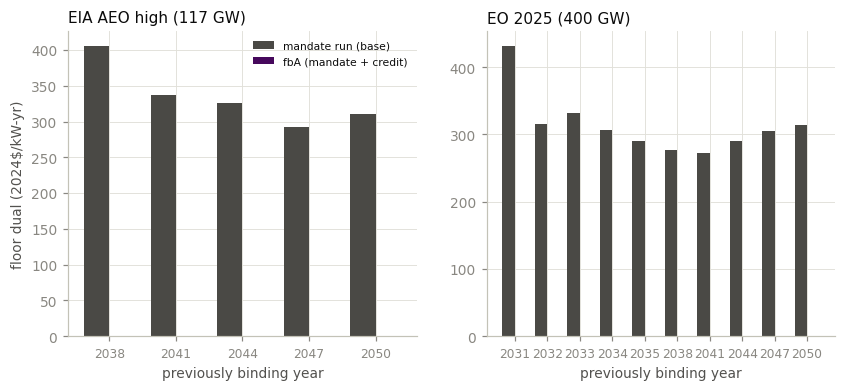

In [6]:
# ---- h01: base dual vs fbA dual ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6), sharey=False)
for ax, c in zip(axes, ["fbA_eia_p50", "fbA_eo_p50"]):
    w = META[c]["world"]
    sub = q01[q01["case"] == c].sort_values("t")
    x = np.arange(len(sub))
    ax.bar(x - 0.19, sub["base_dual_2024_kWyr"], width=0.38, color=BASE_C,
           label="mandate run (base)")
    ax.bar(x + 0.19, sub["fbA_dual_2024_kWyr"], width=0.38, color=SCHED_C[w],
           label="fbA (mandate + credit)")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["t"], rotation=0, fontsize=8)
    ax.set_title(f"{SCHED_LABEL[w]}")
    ax.set_xlabel("previously binding year")
axes[0].set_ylabel("floor dual (2024$/kW-yr)")
axes[0].legend(fontsize=7)
savefig(fig, "h01_fbA_collapse.png")
plt.show()


## R2 — fbB: the convex decentralization control

Mandate off, credit on, learning off. In a convex model the dual-derived
credit reproduces the mandated build. The reproduction tiers repeat the
`itcfb_checks` convention (stated there in phase C): **exact** (|gap| ≤ 5 MW),
**reproduces** (every rate-year and 2050 shortfall ≤ max(5% of trajectory,
500 MW)), **partial** (2050 shortfall ≤ 15%), **no**. Overbuild never fails —
the fed rate carries a +0.01 bump on purpose. Slack-status years get no
credit, so shortfalls there are reported, not gated.

In [7]:
def tier_of(sub):
    """Reproduction tier for one case's gap rows (the itcfb_checks convention)."""
    shortfall = (-sub["gap_MW"]).clip(lower=0.0)
    if float(shortfall.max()) <= 5.0 and float(sub["gap_MW"].abs().max()) <= 5.0:
        return "exact"
    gate = sub[(sub["status"] == "rate") | (sub["t"] == 2050)]
    g_short = (-gate["gap_MW"]).clip(lower=0.0)
    tol1 = np.maximum(0.05 * gate["mandate_MW"], 500.0)
    if bool((g_short <= tol1).all()):
        return "reproduces"
    end = gate[gate["t"] == 2050]
    if len(end) and float(-end["gap_MW"].iloc[0]) <= 0.15 * float(end["mandate_MW"].iloc[0]):
        return "partial"
    return "no"

q02 = GAPS[GAPS["arm"] == "fbB"].copy()
TIER_B = {w: tier_of(q02[q02["world"] == w]) for w in SCHEDULES}
q02["tier"] = q02["world"].map(TIER_B)
q02.to_csv(EXPORTS / "q02_fbB_gaps.csv", index=False)
print("fbB tiers:", TIER_B)
print(q02.groupby("world")["gap_pct"].agg(["min", "max"]).round(2).reindex(SCHEDULES))


fbB tiers: {'eia': 'reproduces', 'aj': 'reproduces', 'iaea': 'reproduces', 'mck': 'reproduces', 'cop28': 'reproduces', 'eo': 'reproduces'}
          min     max
world                
eia    161.95  273.06
aj     109.31  457.73
iaea    62.70  231.76
mck     56.66  168.54
cop28   30.09  260.50
eo      21.90  129.67


saved -> figures\h02_fbB_trajectory_panels.png


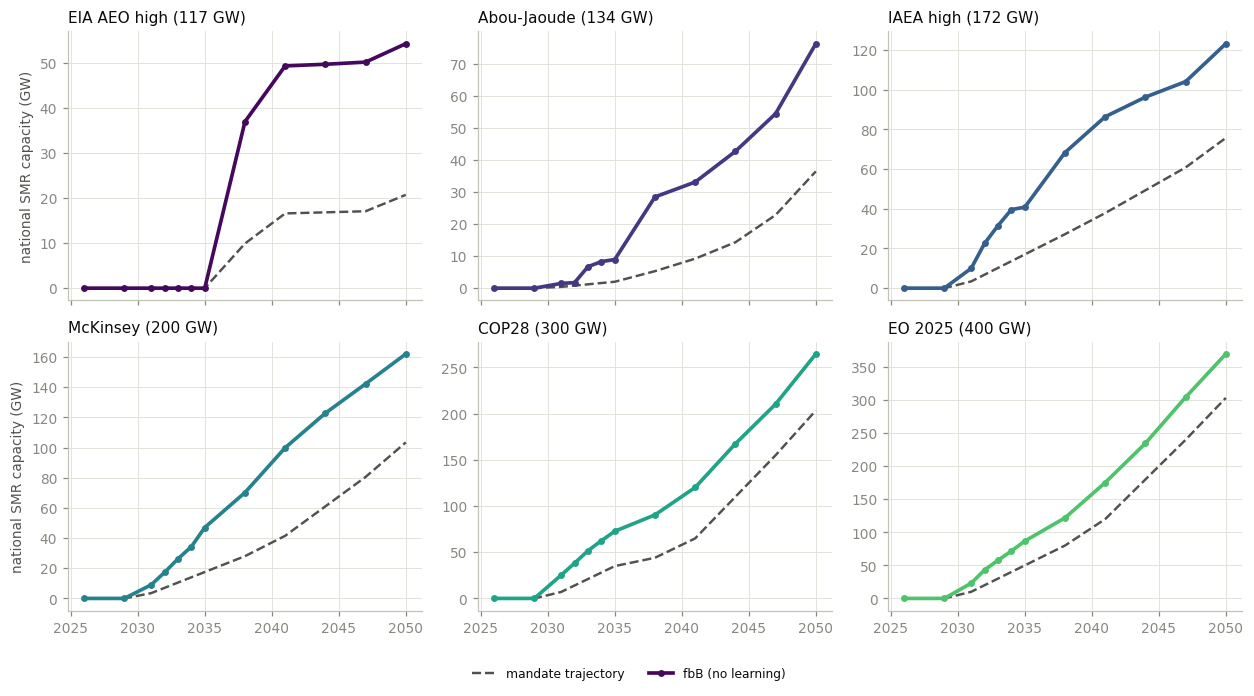

In [8]:
# ---- h02: fbB capacity vs trajectory, 2x3 panels ----------------------------------
def cap_traj_panels(arm_cases, fname, overlay_b=False):
    fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.2), sharex=True)
    for ax, w in zip(axes.ravel(), SCHEDULES):
        tr = TRAJ[w]
        yrs = [t for t in YEARS_RUN if t >= 2026]
        tr_y = [tr.get(t, 0.0) / 1000 for t in yrs]
        ax.plot(yrs, tr_y, color=MUTED, ls="--", lw=1.6, label="mandate trajectory")
        if overlay_b:
            cb = f"fbB_{w}_p50"
            ax.plot(yrs, [SMR_CAP[cb].get(t, 0.0) / 1000 for t in yrs],
                    color=SCHED_C[w], lw=1.4, alpha=0.55, label="fbB (no learning)")
        c = [x for x in arm_cases if META[x]["world"] == w][0]
        lab = "fbC (learning)" if overlay_b else "fbB (no learning)"
        ax.plot(yrs, [SMR_CAP[c].get(t, 0.0) / 1000 for t in yrs],
                color=SCHED_C[w], lw=2.4, marker="o", ms=3.5, label=lab)
        ax.set_title(SCHED_LABEL[w])
        if w in ("eia", "mck"):
            ax.set_ylabel("national SMR capacity (GW)")
    h, l = axes[0, 0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    savefig(fig, fname)
    plt.show()

cap_traj_panels(ARM_CASES["fbB"], "h02_fbB_trajectory_panels.png")


## R3 — fbC: the §9 verdict (pre-registered both ways)

The centerpiece. Same metric, same tiers, with endogenous learning on.

**Verdict logic (a notebook convention, stated once):**

- tier **exact** or **reproduces** ⇒ *"reproduces — method validated for this
  world"*.
- a worse tier is attributed to non-convex learning **only if the controls are
  green**: fbA collapsed, this world's fbB tier is at least "reproduces", fbK
  calibrated, and the solver residuals passed. Otherwise the verdict is
  *"blocked-attribution"*, naming the failed control.
- a **substitution-adjusted** second pass adds the large-reactor capacity built
  in excess of the world's base mandate run (ReEDS choosing its own winner
  under a credit is interpretation, not failure).

Both outcomes are reportable: pass validates the exogenous-price method; fail
is the finding that ITC targets sized without learning are unreliable under
non-convex learning (multiple equilibria; no-build lock-in).

In [9]:
q03 = GAPS[GAPS["arm"] == "fbC"].copy()
TIER_C = {w: tier_of(q03[q03["world"] == w]) for w in SCHEDULES}
q03["tier"] = q03["world"].map(TIER_C)

# substitution-adjusted delivery: SMR + large capacity above the base mandate run
SUBST = {}
for w in SCHEDULES:
    c = f"fbC_{w}_p50"
    b = BASE_OF_WORLD[w]
    extra = {t: max(0.0, float(LG_CAP[c].get(t, 0.0)) - float(LG_CAP[b].get(t, 0.0)))
             for t in YEARS_RUN}
    SUBST[w] = extra
q03["cap_substadj_MW"] = [r.cap_MW + SUBST[r.world][r.t] for r in q03.itertuples()]
q03["gap_substadj_MW"] = (q03["cap_substadj_MW"] - q03["mandate_MW"]).round(1)
q03s = q03.rename(columns={"gap_MW": "gap_raw_MW"})     .rename(columns={"gap_substadj_MW": "gap_MW"})
TIER_CS = {w: tier_of(q03s[q03s["world"] == w]) for w in SCHEDULES}
q03.to_csv(EXPORTS / "q03_fbC_gaps.csv", index=False)
print("fbC tiers:", TIER_C)
print("fbC tiers, substitution-adjusted:", TIER_CS)


fbC tiers: {'eia': 'partial', 'aj': 'reproduces', 'iaea': 'reproduces', 'mck': 'reproduces', 'cop28': 'reproduces', 'eo': 'reproduces'}
fbC tiers, substitution-adjusted: {'eia': 'partial', 'aj': 'reproduces', 'iaea': 'reproduces', 'mck': 'reproduces', 'cop28': 'reproduces', 'eo': 'reproduces'}


In [10]:
# ---- controls: read the named check rows from the registry ------------------------
def check_ok(substr):
    row = summary[summary["check"].str.contains(substr, regex=False)]
    assert len(row) == 1, f"check lookup not unique: {substr}"
    return row["status"].iloc[0] == "PASS"

CTRL = dict(
    fbA_collapse=check_ok("every previously binding floor dual collapses"),
    fbA_floor=check_ok("capacity satisfies the mandate floor"),
    fbK_calibration=check_ok("in-run learned cost path reproduces"),
    solver=check_ok("solver residuals are small"),
)
print("controls:", CTRL)

# ---- q04: the verdict table --------------------------------------------------------
rows = []
for w in SCHEDULES:
    tb, tc, tcs = TIER_B[w], TIER_C[w], TIER_CS[w]
    traj50 = float(TRAJ[w].get(2050))
    dfrac = float(SMR_CAP[f"fbC_{w}_p50"].get(2050, 0.0)) / traj50
    dfrac_s = dfrac + SUBST[w][2050] / traj50
    controls_green = all(CTRL.values()) and tb in ("exact", "reproduces")
    if tc in ("exact", "reproduces"):
        verdict = "reproduces — method validated for this world"
    elif not controls_green:
        bad = [k for k, v in CTRL.items() if not v] +             ([f"fbB tier {tb}"] if tb not in ("exact", "reproduces") else [])
        verdict = f"blocked-attribution ({', '.join(bad)})"
    elif tc == "partial":
        verdict = ("partial — early rate-year shortfall, recovers by 2050"
                   if dfrac >= 1.0 else
                   "partial — under-delivers under endogenous learning")
    else:
        verdict = "does not reproduce — non-convex-learning finding"
    rows.append(dict(world=w, tier_fbB=tb, tier_fbC=tc, tier_fbC_substadj=tcs,
                     delivered_frac_2050=round(dfrac, 3),
                     delivered_frac_2050_substadj=round(dfrac_s, 3),
                     controls_green=controls_green, verdict=verdict))
q04 = pd.DataFrame(rows)
q04.to_csv(EXPORTS / "q04_s9_verdict.csv", index=False)
print(q04.to_string(index=False))

n_ok = int(q04["tier_fbC"].isin(["exact", "reproduces"]).sum())
print(f"\nSECTION-9 READING: the dual-derived credit reproduces the trajectory "
      f"under endogenous learning in {n_ok} of 6 worlds "
      "(pre-registered both ways; see q04 for the per-world verdicts)")


controls: {'fbA_collapse': True, 'fbA_floor': True, 'fbK_calibration': True, 'solver': True}
world   tier_fbB   tier_fbC tier_fbC_substadj  delivered_frac_2050  delivered_frac_2050_substadj  controls_green                                               verdict
  eia reproduces    partial           partial                1.287                         1.287            True partial — early rate-year shortfall, recovers by 2050
   aj reproduces reproduces        reproduces                2.715                         2.715            True          reproduces — method validated for this world
 iaea reproduces reproduces        reproduces                2.719                         2.719            True          reproduces — method validated for this world
  mck reproduces reproduces        reproduces                2.264                         2.264            True          reproduces — method validated for this world
cop28 reproduces reproduces        reproduces                1.547      

saved -> figures\h03_fbC_trajectory_panels.png


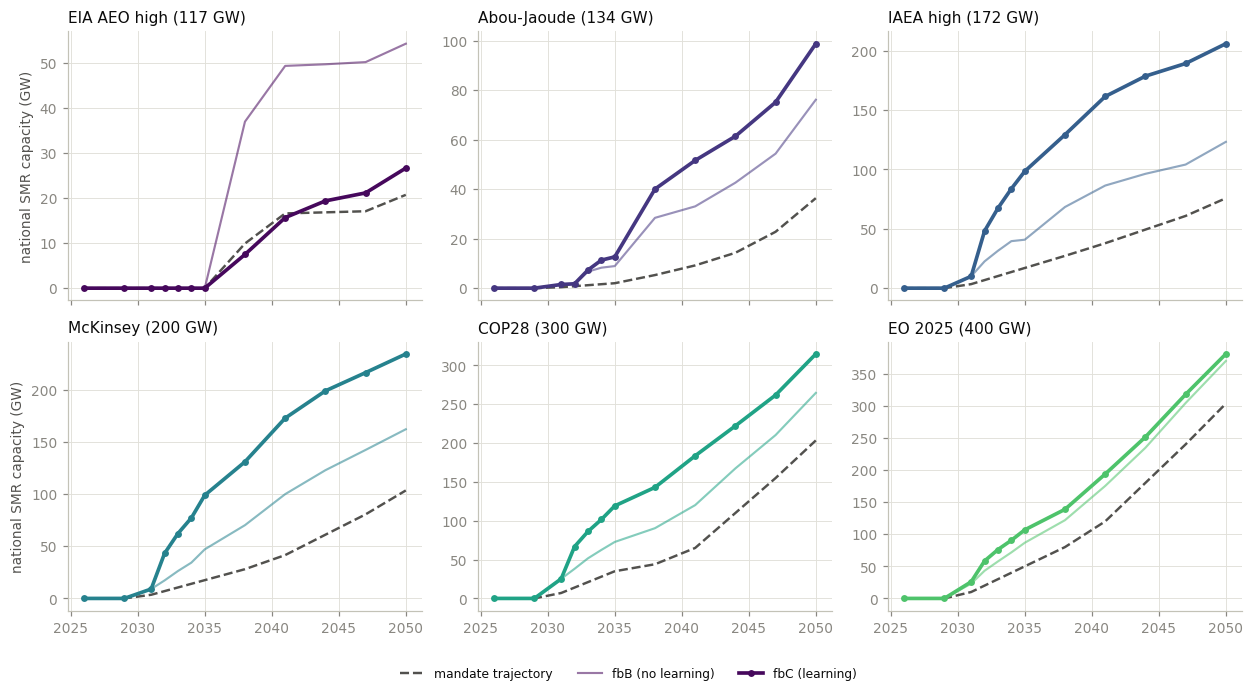

In [11]:
# ---- h03: fbC vs fbB vs trajectory ------------------------------------------------
cap_traj_panels(ARM_CASES["fbC"], "h03_fbC_trajectory_panels.png", overlay_b=True)


saved -> figures\h04_delivery_summary.png


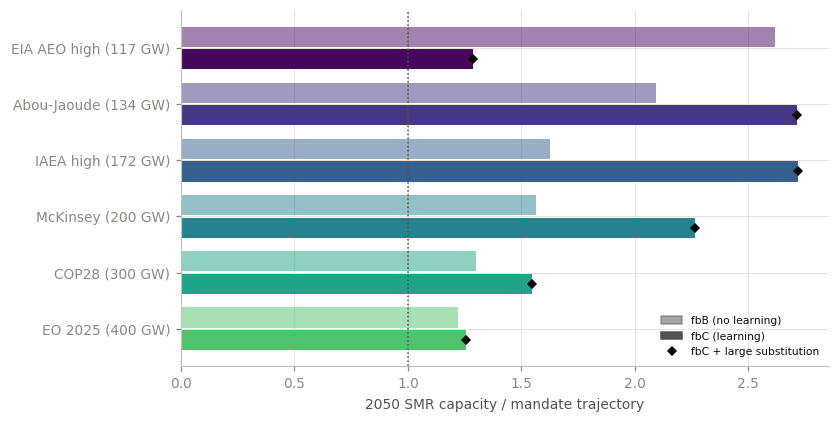

In [12]:
# ---- h04: 2050 delivery summary ---------------------------------------------------
fig, ax = plt.subplots(figsize=(7.6, 4.2))
y = np.arange(len(SCHEDULES))[::-1]
fb = [float(SMR_CAP[f"fbB_{w}_p50"].get(2050, 0.0)) / float(TRAJ[w].get(2050))
      for w in SCHEDULES]
fc = q04.set_index("world")["delivered_frac_2050"].reindex(SCHEDULES).to_numpy()
fcs = q04.set_index("world")["delivered_frac_2050_substadj"].reindex(SCHEDULES).to_numpy()
ax.barh(y + 0.2, fb, height=0.36, color=[SCHED_C[w] for w in SCHEDULES], alpha=0.5,
        label="fbB (no learning)")
ax.barh(y - 0.2, fc, height=0.36, color=[SCHED_C[w] for w in SCHEDULES],
        label="fbC (learning)")
for yi_, s, f_ in zip(y, fcs, fc):
    ax.plot([s], [yi_ - 0.2], marker="D", ms=4, color=INK, ls="")
ax.axvline(1.0, color=MUTED, lw=1.0, ls=":")
ax.set_yticks(y)
ax.set_yticklabels([SCHED_LABEL[w] for w in SCHEDULES])
ax.set_xlabel("2050 SMR capacity / mandate trajectory")
from matplotlib.lines import Line2D
handles = [plt.Rectangle((0, 0), 1, 1, color=MUTED, alpha=0.5),
           plt.Rectangle((0, 0), 1, 1, color=MUTED),
           Line2D([], [], marker="D", ms=4, color=INK, ls="")]
ax.legend(handles, ["fbB (no learning)", "fbC (learning)",
                    "fbC + large substitution"], fontsize=7, loc="best")
savefig(fig, "h04_delivery_summary.png")
plt.show()


## R4 — fbK: the engine calibration

Mandate + endogenous learning, no credit. The in-run learned cost path must
reproduce the drawn p50 plant cost path, so that an fbC miss can be attributed
to economics rather than the learning engine. The comparison table comes from
`itcfb_checks` (C7); the SMR channel from 2031 is the gate, the large channel
is context.

case         i          
fbK_eia_p50  nuclear        1.05e-03
             nuclear-smr    1.88e-01
fbK_eo_p50   nuclear        1.87e-02
             nuclear-smr    3.07e-02
Name: rel_err, dtype: object


saved -> figures\h05_fbK_costpath.png


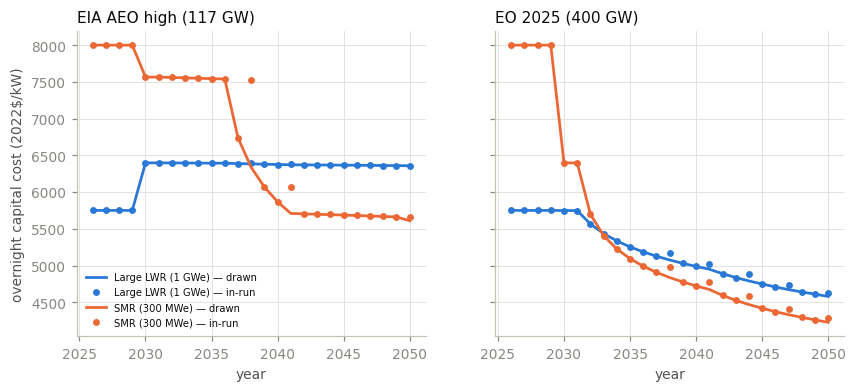

In [13]:
q05 = CAL.copy()
q05["drawn_2022_kW"] = q05["drawn_2004_MW"] / (1000 * D2022)
q05["inrun_2022_kW"] = q05["inrun_2004_MW"] / (1000 * D2022)
q05.to_csv(EXPORTS / "q05_fbK_calibration.csv", index=False)
print(q05.groupby(["case", "i"])["rel_err"].max().map("{:.2e}".format))

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6), sharey=True)
for ax, c in zip(axes, ["fbK_eia_p50", "fbK_eo_p50"]):
    for itech in ["nuclear", "nuclear-smr"]:
        key = "large" if itech == "nuclear" else "smr"
        sub = q05[(q05["case"] == c) & (q05["i"] == itech) & (q05["t"] >= 2026)]             .sort_values("t")
        ax.plot(sub["t"], sub["drawn_2022_kW"], color=COL[key], lw=1.8,
                label=f"{ps.TECH_LABEL[key]} — drawn")
        ax.plot(sub["t"], sub["inrun_2022_kW"], color=COL[key], ls="", marker="o",
                ms=3.5, label=f"{ps.TECH_LABEL[key]} — in-run")
    ax.set_title(SCHED_LABEL[META[c]["world"]])
    ax.set_xlabel("year")
axes[0].set_ylabel(f"overnight capital cost {ps.usd('kW', 2022)}")
axes[0].legend(fontsize=6.5)
savefig(fig, "h05_fbK_costpath.png")
plt.show()


## R5 — The deployment-vs-rate curve

The fbR trio anchors the demand curve at flat monetized rates 0 / 0.27 / 0.45
(both nuclear technologies credited, eia world). Each fed world adds one point:
its mean monetized schedule rate against its 2050 SMR capacity, from fbB and
from fbC. Caveat: the schedule rates are time-varying and SMR-only while the
anchors are flat and both-tech — the anchors bound the curve, they do not
interpolate it.

In [14]:
rows = []
for c in ARM_CASES["fbR"]:
    m = {"fbR_none": 0.0, "fbR_itc30": 0.27, "fbR_itc50": 0.45}[c]
    rows.append(dict(kind="flat-anchor", case=c, world="eia", m_monetized=m,
                     smr_2050_GW=round(float(SMR_CAP[c].get(2050, 0.0)) / 1000, 2),
                     large_2050_GW=round(float(LG_CAP[c].get(2050, 0.0)) / 1000, 2),
                     nuclear_2050_GW=round((float(SMR_CAP[c].get(2050, 0.0))
                                            + float(LG_CAP[c].get(2050, 0.0))) / 1000, 2)))
for arm in ["fbB", "fbC"]:
    for w in SCHEDULES:
        c = f"{arm}_{w}_p50"
        rows.append(dict(kind=f"schedule-{arm}", case=c, world=w,
                         m_monetized=round(float(np.mean(list(RATES[w].values()))), 3),
                         smr_2050_GW=round(float(SMR_CAP[c].get(2050, 0.0)) / 1000, 2),
                         large_2050_GW=round(float(LG_CAP[c].get(2050, 0.0)) / 1000, 2),
                         nuclear_2050_GW=round((float(SMR_CAP[c].get(2050, 0.0))
                                                + float(LG_CAP[c].get(2050, 0.0))) / 1000, 2)))
q06 = pd.DataFrame(rows)
q06.to_csv(EXPORTS / "q06_rate_deployment.csv", index=False)
print(q06.to_string(index=False))


        kind          case world  m_monetized  smr_2050_GW  large_2050_GW  nuclear_2050_GW
 flat-anchor      fbR_none   eia        0.000         0.00          94.11            94.11
 flat-anchor     fbR_itc30   eia        0.270         0.00          94.11            94.11
 flat-anchor     fbR_itc50   eia        0.450         9.79          94.11           103.89
schedule-fbB   fbB_eia_p50   eia        0.543        54.22          94.11           148.33
schedule-fbB    fbB_aj_p50    aj        0.569        76.19          94.11           170.29
schedule-fbB  fbB_iaea_p50  iaea        0.648       123.16          94.11           217.27
schedule-fbB   fbB_mck_p50   mck        0.624       161.98          94.11           256.09
schedule-fbB fbB_cop28_p50 cop28        0.671       264.61          94.11           358.72
schedule-fbB    fbB_eo_p50    eo        0.622       369.83          94.11           463.94
schedule-fbC   fbC_eia_p50   eia        0.543        26.63          94.11           120.74

saved -> figures\h06_deployment_vs_rate.png


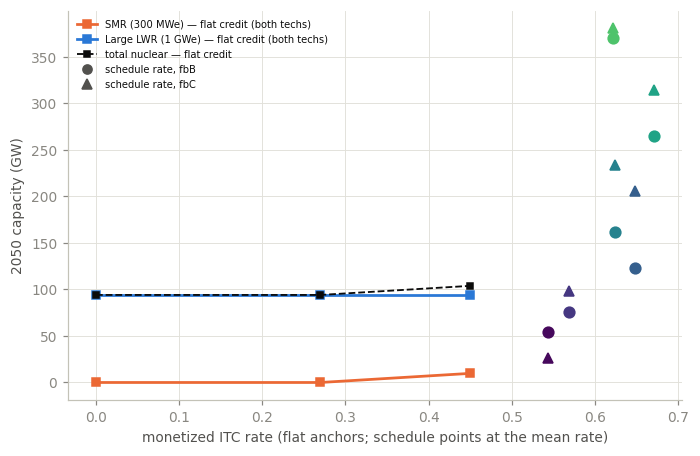

In [15]:
# ---- h06: deployment vs rate ------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.6))
anch = q06[q06["kind"] == "flat-anchor"].sort_values("m_monetized")
for key, col_name in [("smr", "smr_2050_GW"), ("large", "large_2050_GW")]:
    ax.plot(anch["m_monetized"], anch[col_name], color=COL[key], lw=1.8, marker="s",
            ms=5, label=f"{ps.TECH_LABEL[key]} — flat credit (both techs)")
ax.plot(anch["m_monetized"], anch["nuclear_2050_GW"], color=INK, lw=1.2, ls="--",
        marker="s", ms=4, label="total nuclear — flat credit")
for arm, mk in [("fbB", "o"), ("fbC", "^")]:
    sub = q06[q06["kind"] == f"schedule-{arm}"]
    for r in sub.itertuples():
        ax.plot(r.m_monetized, r.smr_2050_GW, marker=mk, ms=7, ls="",
                color=SCHED_C[r.world])
from matplotlib.lines import Line2D
extra = [Line2D([], [], marker="o", ls="", color=MUTED, label="schedule rate, fbB"),
         Line2D([], [], marker="^", ls="", color=MUTED, label="schedule rate, fbC")]
h_, l_ = ax.get_legend_handles_labels()
ax.legend(handles=h_ + extra, fontsize=6.5, loc="upper left")
ax.set_xlabel("monetized ITC rate (flat anchors; schedule points at the mean rate)")
ax.set_ylabel("2050 capacity (GW)")
savefig(fig, "h06_deployment_vs_rate.png")
plt.show()


## R6 — Large-reactor substitution (context)

The credit does not force the SMR: under a design-neutral flat credit (fbR)
and even under the SMR-only schedule credit (fbB/fbC), ReEDS picks its own
winner. Substitution is interpretation, not failure — it is reported here and
folded into the substitution-adjusted verdict column of q04.

         case arm world  smr_2050_GW  large_2050_GW  new_large_post2030_GW  base_large_2050_GW  large_above_base_GW
  fbA_eia_p50 fbA   eia        54.22          94.11                    0.0               94.11                  0.0
   fbA_eo_p50 fbA    eo       369.83          94.11                    0.0               94.11                  0.0
  fbB_eia_p50 fbB   eia        54.22          94.11                    0.0               94.11                  0.0
   fbB_aj_p50 fbB    aj        76.19          94.11                    0.0               94.11                  0.0
 fbB_iaea_p50 fbB  iaea       123.16          94.11                    0.0               94.11                  0.0
  fbB_mck_p50 fbB   mck       161.98          94.11                    0.0               94.11                  0.0
fbB_cop28_p50 fbB cop28       264.61          94.11                    0.0               94.11                  0.0
   fbB_eo_p50 fbB    eo       369.83          94.11                    0

saved -> figures\h07_substitution.png


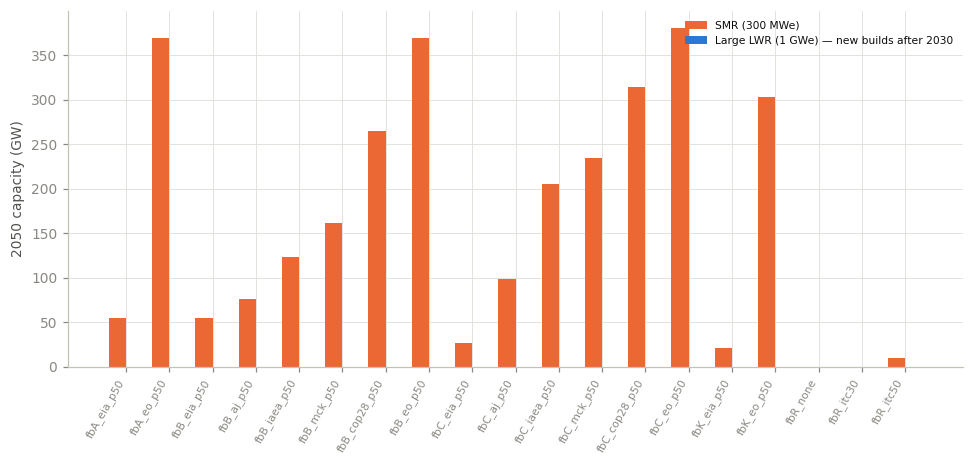

In [16]:
q07 = q00[["case", "arm", "world", "smr_2050_GW", "large_2050_GW",
           "new_large_post2030_GW"]].copy()
base_lg = {w: round(float(LG_CAP[BASE_OF_WORLD[w]].get(2050, 0.0)) / 1000, 2)
           for w in SCHEDULES}
q07["base_large_2050_GW"] = q07["world"].map(base_lg)
q07["large_above_base_GW"] = (q07["large_2050_GW"] - q07["base_large_2050_GW"]).round(2)
q07.to_csv(EXPORTS / "q07_large_substitution.csv", index=False)
print(q07.to_string(index=False))

fig, ax = plt.subplots(figsize=(10.5, 4.2))
x = np.arange(len(CASES))
order = ARM_CASES["fbA"] + ARM_CASES["fbB"] + ARM_CASES["fbC"] + ARM_CASES["fbK"]     + ARM_CASES["fbR"]
q = q07.set_index("case").reindex(order)
ax.bar(x - 0.2, q["smr_2050_GW"], width=0.4, color=COL["smr"],
       label=ps.TECH_LABEL["smr"])
ax.bar(x + 0.2, q["new_large_post2030_GW"], width=0.4, color=COL["large"],
       label=f"{ps.TECH_LABEL['large']} — new builds after 2030")
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=60, ha="right", fontsize=7)
ax.set_ylabel("2050 capacity (GW)")
ax.legend(fontsize=7)
savefig(fig, "h07_substitution.png")
plt.show()


## R7 — Caveats and output manifest

- **Myopic sequential solve:** the engine sees one year at a time, which shapes
  what "decentralizing the target" means; the fbB control carries the same
  myopia, so the fbC-vs-fbB contrast isolates learning, not foresight.
- **Solve years only:** the trajectory file is annual but the model solves 12
  years in 2026–2050; every comparison is at solve years. Capacity is
  cumulative all-vintage — the basis the mandate counts.
- **Dollar conventions:** duals are 2004$ internally; displays use x TO2024.
  Costs plot in 2022$/kW to match the plant input files.
- **Tier thresholds are notebook conventions** (5 MW / max(5%, 500 MW) / 15%),
  stated in R2 and exported with the data so any reader can re-cut them.
- **Exclusions are findings:** the p95 worlds (the required rate exceeds 100%
  in late case-years — an ITC alone provably cannot deliver them) and the
  large100 family (early-year duals price fleet retention, which an investment
  credit on new builds cannot buy) were excluded by design; rationale in
  `z-ethan/itc_feedback/run_manifest.md`.
- **The demand-curve anchors bound, they do not interpolate** (flat both-tech
  credits vs time-varying SMR-only schedules).

In [17]:
manifest = sorted(p.name for p in EXPORTS.glob("q0*.csv")) \
    + sorted(p.name for p in FIGURES.glob("h0*.png"))
print("outputs written by this notebook:")
for m_ in manifest:
    print(" ", m_)


outputs written by this notebook:
  q00_run_inventory.csv
  q01_fbA_dual_collapse.csv
  q02_fbB_gaps.csv
  q03_fbC_gaps.csv
  q04_s9_verdict.csv
  q05_fbK_calibration.csv
  q06_rate_deployment.csv
  q07_large_substitution.csv
  h01_fbA_collapse.png
  h02_fbB_trajectory_panels.png
  h03_fbC_trajectory_panels.png
  h04_delivery_summary.png
  h05_fbK_costpath.png
  h06_deployment_vs_rate.png
  h07_substitution.png
